# HMDA 2024 Mortgage Lending Analysis

## HMDA (Home Mortgage Disclosure Act) Data set ## 
Objective: To analyze the 2024 HMDA Loan Application Register and identify systematic patterns in mortgage loan type distribution across racial groups, income brackets, and geographic regions, with the aim of surfacing potential loan-type mismatches and informing fair lending policy recommendations.
Modeling notebook for a four-person graduate group project (Northeastern University). Cleans the CFPB 2024 HMDA Loan Application Register extract to 465,939 originated loans, profiles borrowers with K-Means, and predicts loan-type mismatches with logistic regression and gradient boosting.

In [3]:
# Import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the 2024 Public LAR data
df_lar = pd.read_excel('2024_public_loan.xlsx')

# Preview
print(f"Shape: {df_lar.shape[0]:,} rows × {df_lar.shape[1]} cols")
display(df_lar.head())

# Column overview
print("\n--- Data Types & Null Counts ---")
df_lar.info()

# Summary stats
display(df_lar.describe(include='all'))


Shape: 1,048,575 rows × 99 cols


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,WWB2V0FCW3A0EE3ZJN75,14860,CT,9190.0,9.190211e+09,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,5877,80.84,146500,40,554,1715,67
1,2024,WWB2V0FCW3A0EE3ZJN75,35300,CT,9170.0,9.170194e+09,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2045,6.26,116200,132,834,1455,59
2,2024,WWB2V0FCW3A0EE3ZJN75,99999,PA,42107.0,4.210700e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3364,12.13,81400,107,1338,1974,0
3,2024,WWB2V0FCW3A0EE3ZJN75,29540,PA,42071.0,4.207101e+10,C,Conventional:Subordinate Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5221,7.03,106700,107,1600,1891,34
4,2024,WWB2V0FCW3A0EE3ZJN75,99999,PA,42057.0,4.205796e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4692,5.58,81400,112,1514,2130,41



--- Data Types & Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 99 columns):
 #   Column                                    Non-Null Count    Dtype  
---  ------                                    --------------    -----  
 0   activity_year                             1048575 non-null  int64  
 1   lei                                       1048575 non-null  object 
 2   derived_msa_md                            1048575 non-null  int64  
 3   state_code                                1035886 non-null  object 
 4   county_code                               1031364 non-null  float64
 5   census_tract                              1032017 non-null  float64
 6   conforming_loan_limit                     1045285 non-null  object 
 7   derived_loan_product_type                 1048575 non-null  object 
 8   derived_dwelling_category                 1048575 non-null  object 
 9   derived_ethnicity                         104

,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
count,1048575.0,1048575,1.048575e+06,1035886,1.031364e+06,1.032017e+06,1045285,1048575,1048575,1048575,...,56062.000000,14014.000000,1421.000000,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
unique,NaN,244,NaN,52,NaN,NaN,3,8,4,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,6BYL5QZYBDK8S7L73M02,NaN,OH,NaN,NaN,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,202480,NaN,90209,NaN,NaN,1005090,495983,1022087,716341,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024.0,NaN,3.933887e+04,NaN,2.818530e+04,2.818307e+10,NaN,NaN,NaN,NaN,...,3.841426,5.377551,7.357495,4.662716e+03,3.425858e+01,9.960369e+04,1.091669e+02,1.212207e+03,1.635351e+03,3.715905e+01
std,0.0,NaN,2.671840e+04,NaN,1.511139e+04,1.510185e+10,NaN,NaN,NaN,NaN,...,2.483927,2.107396,1.991601,2.074724e+03,2.578218e+01,2.433728e+04,4.370221e+01,5.767772e+02,6.837439e+02,1.913288e+01
min,2024.0,NaN,1.018000e+04,NaN,1.001000e+03,1.001020e+09,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2024.0,NaN,1.974000e+04,NaN,1.317900e+04,1.318197e+10,NaN,NaN,NaN,NaN,...,2.000000,4.000000,6.000000,3.352000e+03,1.353000e+01,8.670000e+04,8.300000e+01,8.150000e+02,1.195000e+03,2.400000e+01
50%,2024.0,NaN,3.346000e+04,NaN,2.803300e+04,2.803501e+10,NaN,NaN,NaN,NaN,...,3.000000,5.000000,9.000000,4.457000e+03,2.627000e+01,9.820000e+04,1.050000e+02,1.168000e+03,1.600000e+03,3.700000e+01
75%,2024.0,NaN,4.194000e+04,NaN,3.917300e+04,3.916900e+10,NaN,NaN,NaN,NaN,...,5.000000,6.000000,9.000000,5.726000e+03,4.937000e+01,1.098000e+05,1.310000e+02,1.560000e+03,2.035000e+03,5.100000e+01


# Data Cleaning and Exploration

In [4]:
# Check for missing values
missing_values = df_lar.isnull().sum()
print("\n--- Missing Values ---")
print(missing_values)

# Check for duplicates
duplicate_count = df_lar.duplicated().sum()
print(f"\n--- Duplicate Rows ---\n{duplicate_count:,} duplicates found")



--- Missing Values ---
activity_year                            0
lei                                      0
derived_msa_md                           0
state_code                           12689
county_code                          17211
                                     ...  
ffiec_msa_md_median_family_income        0
tract_to_msa_income_percentage           0
tract_owner_occupied_units               0
tract_one_to_four_family_homes           0
tract_median_age_of_housing_units        0
Length: 99, dtype: int64

--- Duplicate Rows ---
951 duplicates found


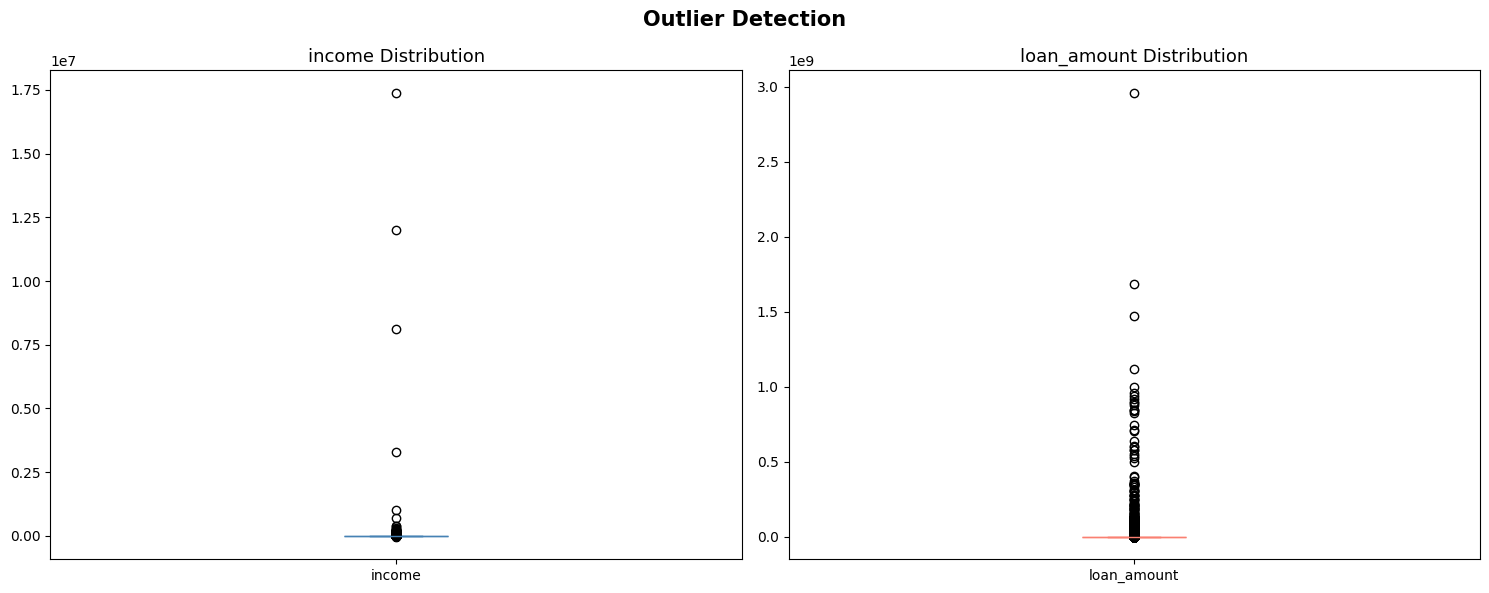

              income   loan_amount
count  903928.000000  9.039280e+05
mean      125.999278  2.438177e+05
std       103.806758  2.259728e+05
min    -42909.000000  5.000000e+03
25%        65.000000  8.500000e+04
50%       101.000000  1.850000e+05
75%       161.000000  3.250000e+05
max       500.000000  2.995000e+06


In [5]:
# Check for outlier 
df_lar[['income', 'loan_amount']].describe()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cols = ['income', 'loan_amount']
colors = ['steelblue', 'salmon']

for ax, col, color in zip(axes, cols, colors):
    df_lar[col].dropna().plot.box(ax=ax, color=color, patch_artist=True)
    ax.set_title(f'{col} Distribution', fontsize=13)
    ax.set_xlabel('')

plt.suptitle('Outlier Detection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Remove extreme income outliers (keep under $500k annual income)
df_lar = df_lar[df_lar['income'] <= 500]  # HMDA income is in thousands

# Remove extreme loan amount outliers (keep under $3 million)
df_lar = df_lar[df_lar['loan_amount'] <= 3000000]

print(df_lar[['income', 'loan_amount']].describe())



In [6]:
# Remove negative income values
df_lar = df_lar[df_lar['income'] >= 0]

In [7]:
# Check the data value in DTI column
print(df_lar['debt_to_income_ratio'].value_counts().head(30))
print(f"\nUnique values: {df_lar['debt_to_income_ratio'].nunique()}")

debt_to_income_ratio
20%-<30%    90698
30%-<36%    90608
>60%        77570
50%-60%     76488
<20%        37848
49          33879
44          27983
42          23992
43          22390
41          21596
48          20959
40          20948
39          20500
45          19755
47          19742
38          19152
46          19066
37          18776
36          17602
Exempt       9175
Name: count, dtype: int64

Unique values: 20


**Data Cleaning : Remove column & Impute Value**

In [8]:
# Check missing values after cleaning
cols = ['loan_type', 'derived_race', 'income', 'debt_to_income_ratio', 
        'interest_rate', 'loan_amount', 'state_code', 
        'tract_minority_population_percent', 'action_taken', 'loan_purpose']

df = df_lar[cols].copy()
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")


loan_type                                 0
derived_race                              0
income                                    0
debt_to_income_ratio                 214076
interest_rate                        334283
loan_amount                               0
state_code                            12436
tract_minority_population_percent         0
action_taken                              0
loan_purpose                              0
dtype: int64

Total rows: 902803


In [9]:
# handle missing value; DTI Column

# Map DTI to numeric midpoints
dti_map = {
    '<20%': 10,
    '20%-<30%': 25,
    '30%-<36%': 33,
    '36': 36, '37': 37, '38': 38, '39': 39, '40': 40,
    '41': 41, '42': 42, '43': 43, '44': 44, '45': 45,
    '46': 46, '47': 47, '48': 48, '49': 49,
    '50%-60%': 55,
    '>60%': 65,
    'Exempt': None  # treat as missing
}

df_lar['debt_to_income_ratio'] = df_lar['debt_to_income_ratio'].astype(str).map(dti_map)

print(df_lar['debt_to_income_ratio'].value_counts())
print(f"\nMissing after mapping: {df_lar['debt_to_income_ratio'].isnull().sum()}")

debt_to_income_ratio
25.0    90698
33.0    90608
65.0    77570
55.0    76488
10.0    37848
49.0    33879
44.0    27983
42.0    23992
43.0    22390
41.0    21596
48.0    20959
40.0    20948
39.0    20500
45.0    19755
47.0    19742
38.0    19152
46.0    19066
37.0    18776
36.0    17602
Name: count, dtype: int64

Missing after mapping: 223251


Median DTI: 42.0
count    679552.000000
mean         41.241250
std          13.889715
min          10.000000
25%          33.000000
50%          42.000000
75%          49.000000
max          65.000000
Name: debt_to_income_ratio, dtype: float64


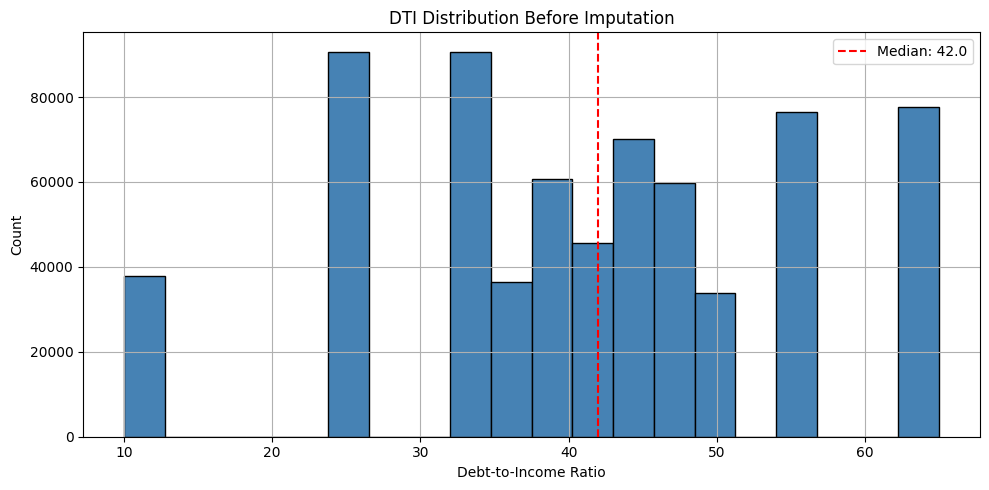

In [10]:
# Check median before imputation for DTI
print(f"Median DTI: {df_lar['debt_to_income_ratio'].median()}")
print(df_lar['debt_to_income_ratio'].describe())

plt.figure(figsize=(10, 5))
df_lar['debt_to_income_ratio'].dropna().hist(bins=20, color='steelblue', edgecolor='black')
plt.title('DTI Distribution Before Imputation')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Count')
plt.axvline(df_lar['debt_to_income_ratio'].median(), color='red', linestyle='--', label=f'Median: {df_lar["debt_to_income_ratio"].median()}')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Imputing missing DTI values with median
median_dti = df_lar['debt_to_income_ratio'].median()
df_lar['debt_to_income_ratio'] = df_lar['debt_to_income_ratio'].fillna(median_dti)
print(f"Imputed DTI with median: {median_dti}")
print(f"Missing after impute: {df_lar['debt_to_income_ratio'].isnull().sum()}")

Imputed DTI with median: 42.0
Missing after impute: 0


In [12]:
# Handle missing value for interest rate
df_lar['interest_rate'] = df_lar['interest_rate'].replace('Exempt', None)
df_lar['interest_rate'] = pd.to_numeric(df_lar['interest_rate'], errors='coerce')

median_rate = df_lar['interest_rate'].median()
df_lar['interest_rate'] = df_lar['interest_rate'].fillna(median_rate)
print(f"Imputed interest_rate with median: {median_rate}")
print(f"Missing after impute: {df_lar['interest_rate'].isnull().sum()}")

Imputed interest_rate with median: 7.0
Missing after impute: 0


In [13]:
# handle missing value, by dropnull in state_code and drop irrelevant columns
cols = ['loan_type', 'derived_race', 'income', 'debt_to_income_ratio', 
        'interest_rate', 'loan_amount', 'state_code', 
        'tract_minority_population_percent', 'action_taken', 'loan_purpose',
         'derived_sex', 'applicant_age']

df = df_lar[cols].copy()
df = df.dropna(subset = ['state_code'])

print(f"Final shape: {df.shape}")
print(df.isnull().sum())

Final shape: (890367, 12)
loan_type                            0
derived_race                         0
income                               0
debt_to_income_ratio                 0
interest_rate                        0
loan_amount                          0
state_code                           0
tract_minority_population_percent    0
action_taken                         0
loan_purpose                         0
derived_sex                          0
applicant_age                        0
dtype: int64


In [14]:
# Filter originated loans only
df = df[df['action_taken'] == 1]

# Map loan type
df['loan_type'] = df['loan_type'].map({1: 'Conventional', 2: 'FHA', 3: 'VA', 4: 'USDA'})

print(f"Shape after filtering: {df.shape}")
print(df['loan_type'].value_counts())
print(df['derived_race'].value_counts())
print(df['applicant_age'].value_counts())

Shape after filtering: (465970, 12)
loan_type
Conventional    383538
FHA              54159
VA               25401
USDA              2872
Name: count, dtype: int64
derived_race
White                                        336176
Race Not Available                            54474
Black or African American                     33403
Asian                                         27515
Joint                                         10428
American Indian or Alaska Native               2478
Native Hawaiian or Other Pacific Islander       754
2 or more minority races                        711
Free Form Text Only                              31
Name: count, dtype: int64
applicant_age
35-44    109776
45-54     96237
25-34     88608
55-64     81210
65-74     53154
>74       21723
<25       15167
8888         95
Name: count, dtype: int64


In [15]:
# Drop 8888 age placeholders and Free Form Text race
df = df[df['applicant_age'] != '8888']
df = df[df['derived_race'] != 'Free Form Text Only']

print(f"Final shape: {df.shape}")
print(df.isnull().sum())

Final shape: (465939, 12)
loan_type                            0
derived_race                         0
income                               0
debt_to_income_ratio                 0
interest_rate                        0
loan_amount                          0
state_code                           0
tract_minority_population_percent    0
action_taken                         0
loan_purpose                         0
derived_sex                          0
applicant_age                        0
dtype: int64


In [16]:
# Export cleaned data to CSV 
df.to_csv( 'cleaned_loan_data.csv', index=False)

# Export Data to create dashbard in Tabelau and R shiny

# Predictive Modeling 
**Build a model to flag borrowers at risk of "mismatch" (Strong/High profile in FHA)**


**Methodology: Logictic Regression & Gradient Boosting**



In [17]:
# Import additional libraries for modeling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)


# K-Means Clustering
**Group borrowers into 4 financial profiles: Low / Moderate / Strong / High**

In [18]:

# Features used for clustering
cluster_features = ['income', 'debt_to_income_ratio', 'interest_rate', 'loan_amount']

# Scale features so each contributes equally to the distance calculation
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df[cluster_features])

# Fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster)

# Inspect cluster centers (in original units) so we can interpret them
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=cluster_features)
centers_df['count'] = df['cluster'].value_counts().sort_index().values
print("Cluster centers (original units):")
print(centers_df.round(2))


Cluster centers (original units):
   income  debt_to_income_ratio  interest_rate  loan_amount   count
0  299.03                 37.56           6.91    681816.05   59304
1   95.43                 42.65           6.41    255098.20  196503
2  112.62                 44.70           9.35    111160.08  112160
3  161.26                 23.07           7.34    167705.49   97972


In [19]:
# Name clusters by income rank: lowest = Low, highest = High
income_rank = centers_df['income'].rank().astype(int)
name_order = ['Low', 'Moderate', 'Strong', 'High']
cluster_names = {cid: name_order[r - 1] for cid, r in income_rank.items()}
df['cluster_name'] = df['cluster'].map(cluster_names)

print("Cluster sizes:")
print(df['cluster_name'].value_counts())
print("\nCluster averages:")
print(df.groupby('cluster_name')[cluster_features].mean().round(2))

# %%
# Create the mismatch label
# Mismatch = Strong or High profile borrower who ended up in FHA
df['mismatch'] = ((df['cluster_name'].isin(['Strong', 'High'])) &
                  (df['loan_type'] == 'FHA')).astype(int)

print(f"Mismatch rate: {df['mismatch'].mean():.2%}")
print(f"Total mismatches: {df['mismatch'].sum():,}")

Cluster sizes:
cluster_name
Low         196503
Moderate    112160
Strong       97972
High         59304
Name: count, dtype: int64

Cluster averages:
              income  debt_to_income_ratio  interest_rate  loan_amount
cluster_name                                                          
High          298.99                 37.58           6.91    682354.82
Low            95.44                 42.64           6.41    255029.31
Moderate      112.61                 44.69           9.35    111165.66
Strong        161.46                 23.07           7.34    167857.96
Mismatch rate: 1.47%
Total mismatches: 6,831


# Logistic Regression
**Interpretable model: tells us WHY mismatch happens**

In [20]:
# Prepare features (do NOT include loan_type, since mismatch is defined from it)
numeric_features = ['income', 'debt_to_income_ratio', 'tract_minority_population_percent']
categorical_features = ['derived_race', 'derived_sex', 'applicant_age', 'state_code']

X = df[numeric_features + categorical_features].copy()
y = df['mismatch']

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Class balance: {y.value_counts(normalize=True).round(4).to_dict()}")



Feature matrix shape: (465939, 71)
Class balance: {0: 0.9853, 1: 0.0147}


In [21]:
# Train/test split, stratified by state so every state appears in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df['state_code']
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")

Train: 372,751 rows
Test:  93,188 rows


In [25]:
# Fit logistic regression
# class_weight='balanced' helps because mismatch is rare
log_reg = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, target_names=['Not Mismatch', 'Mismatch']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

=== Logistic Regression Results ===
              precision    recall  f1-score   support

Not Mismatch       1.00      0.72      0.83     91874
    Mismatch       0.04      0.75      0.07      1314

    accuracy                           0.72     93188
   macro avg       0.52      0.73      0.45     93188
weighted avg       0.98      0.72      0.82     93188

ROC-AUC: 0.8008


In [26]:
# Look at coefficients to see which features drive mismatch
# Positive = increases mismatch risk, Negative = decreases
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 15 most influential features:")
print(coef_df.head(15))

Top 15 most influential features:
                                          feature  coefficient
66                                  state_code_VT    -3.795290
42                                  state_code_MN    -1.522115
18                              applicant_age_<25     1.172436
25                                  state_code_CT    -1.124750
39                                  state_code_MD     1.095869
69                                  state_code_WV     1.093020
3   derived_race_American Indian or Alaska Native     1.059923
19                              applicant_age_>74    -1.055349
53                                  state_code_NY     0.947023
59                                  state_code_RI    -0.925098
48                                  state_code_NE    -0.904725
55                                  state_code_OK     0.882793
21                                  state_code_AR     0.836581
4                              derived_race_Asian    -0.830487
40                   

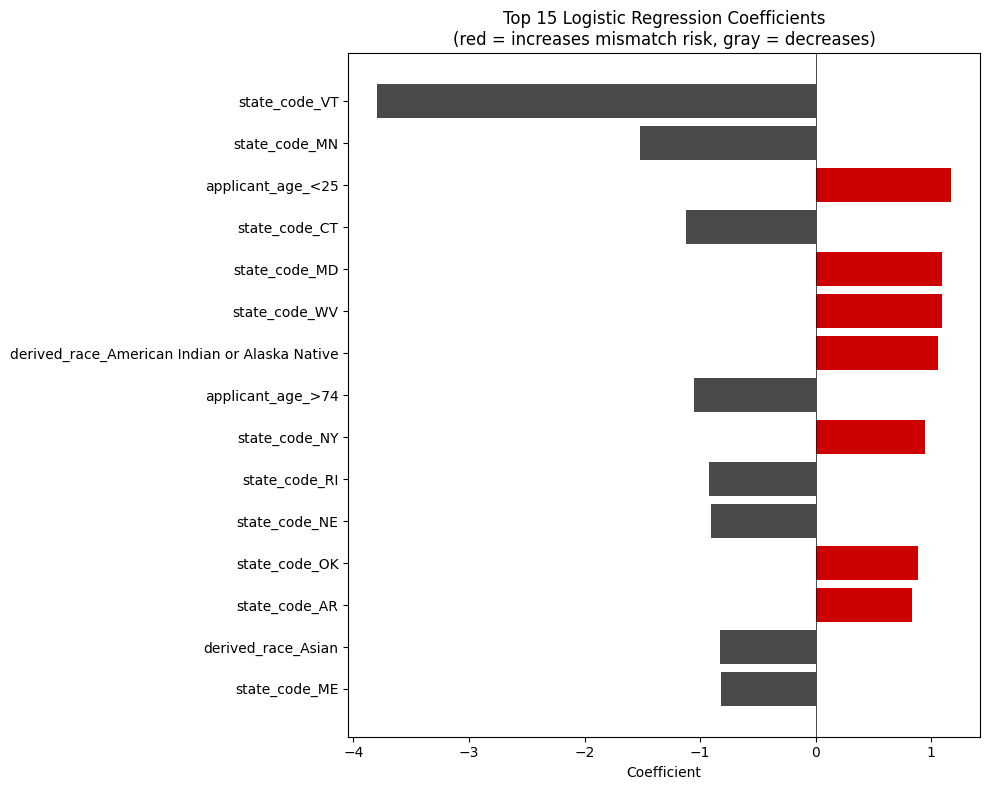

In [27]:
# Visualize top 15 coefficients
top15 = coef_df.head(15).iloc[::-1]
colors = ['#CC0000' if c > 0 else '#4A4A4A' for c in top15['coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(top15['feature'], top15['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Top 15 Logistic Regression Coefficients\n(red = increases mismatch risk, gray = decreases)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

# Gradient Boosting
**Higher-accuracy model: tells us HOW WELL we can predict mismatch**

In [28]:
gb = GradientBoostingClassifier(
    n_estimators=100,     # number of trees
    max_depth=4,          # max depth per tree
    learning_rate=0.1,    # how much each tree contributes
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting Results ===")
print(classification_report(y_test, y_pred_gb, target_names=['Not Mismatch', 'Mismatch']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")


=== Gradient Boosting Results ===
              precision    recall  f1-score   support

Not Mismatch       0.99      1.00      0.99     91874
    Mismatch       0.43      0.02      0.03      1314

    accuracy                           0.99     93188
   macro avg       0.71      0.51      0.51     93188
weighted avg       0.98      0.99      0.98     93188

ROC-AUC: 0.9059


Top 15 most important features:
                                          feature  importance
1                            debt_to_income_ratio    0.316364
0                                          income    0.272392
2               tract_minority_population_percent    0.102285
5          derived_race_Black or African American    0.054627
18                              applicant_age_<25    0.047167
3   derived_race_American Indian or Alaska Native    0.027415
13                            applicant_age_25-34    0.026368
17                            applicant_age_65-74    0.015700
55                                  state_code_OK    0.013506
19                              applicant_age_>74    0.012224
46                                  state_code_NC    0.009196
39                                  state_code_MD    0.008260
37                                  state_code_LA    0.007639
29                                  state_code_GA    0.006406
42                                  st

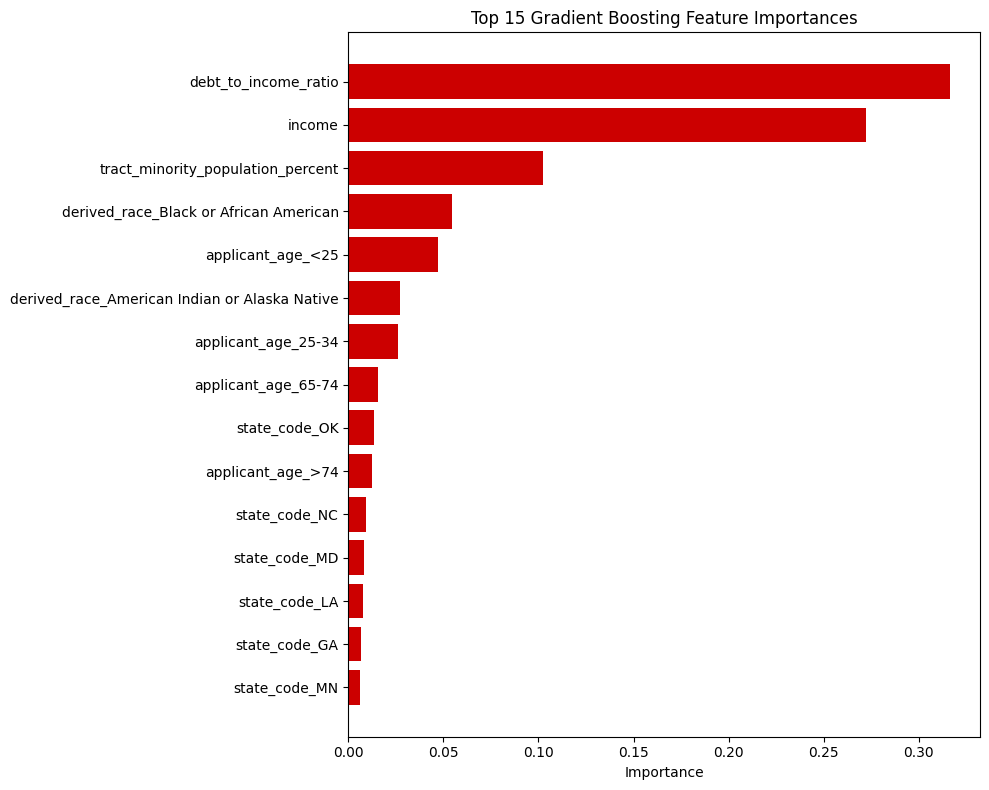

In [29]:
# Feature importance from gradient boosting
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 most important features:")
print(importance_df.head(15))

# %%
# Visualize feature importance
top15_imp = importance_df.head(15).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top15_imp['feature'], top15_imp['importance'], color='#CC0000')
plt.title('Top 15 Gradient Boosting Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Compare Predictive modeling

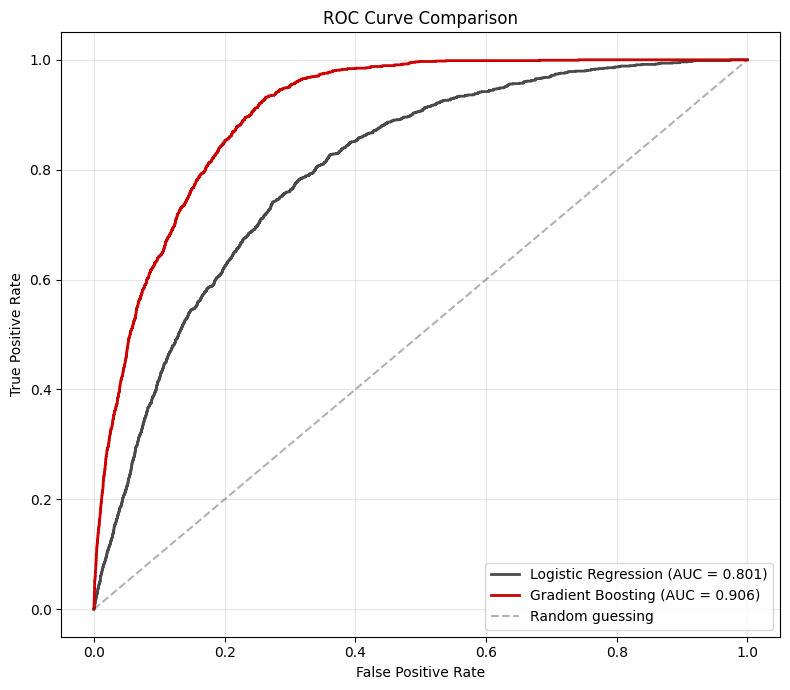

In [30]:
# ROC curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_gb = roc_auc_score(y_test, y_proba_gb)

plt.figure(figsize=(8, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})',
         color='#4A4A4A', linewidth=2)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})',
         color='#CC0000', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
print(f"\nLogistic Regression AUC: {auc_lr:.4f}")
print(f"Gradient Boosting AUC:   {auc_gb:.4f}")
print(f"Improvement: {(auc_gb - auc_lr):.4f}")


Logistic Regression AUC: 0.8008
Gradient Boosting AUC:   0.9059
Improvement: 0.1051


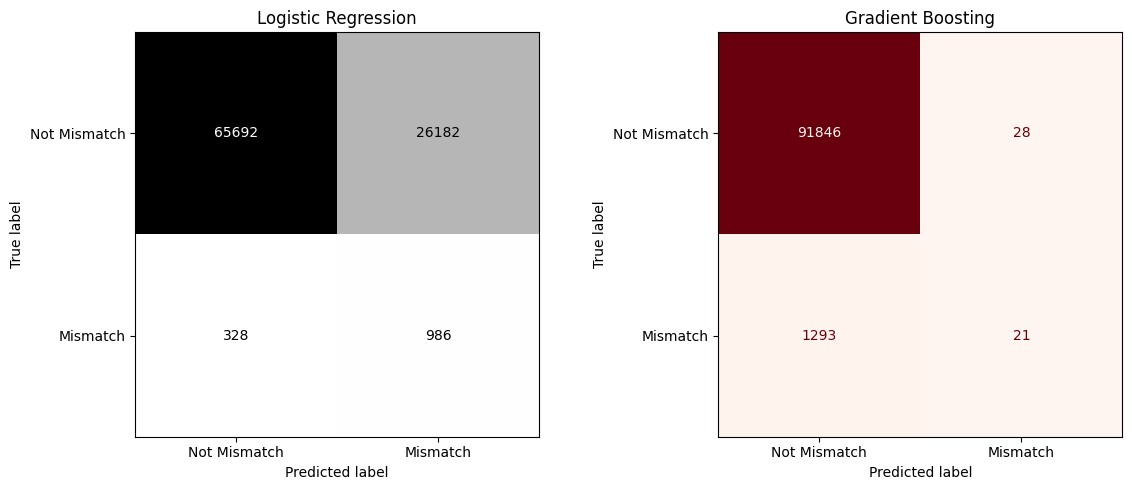

In [32]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Not Mismatch', 'Mismatch']).plot(
    ax=axes[0], cmap='Greys', colorbar=False)
axes[0].set_title('Logistic Regression')

cm_gb = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(cm_gb, display_labels=['Not Mismatch', 'Mismatch']).plot(
    ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Gradient Boosting')

plt.tight_layout()
plt.show()


# Predictive Model: State-level Performance Check
**Does the model work well in our highlight states (MD, WV, LA)?**


In [33]:

# Get state info for test set rows
df_test = df.loc[X_test.index].copy()
df_test['y_true'] = y_test.values
df_test['y_pred_lr'] = y_pred_lr
df_test['y_proba_lr'] = y_proba_lr
df_test['y_pred_gb'] = y_pred_gb
df_test['y_proba_gb'] = y_proba_gb

# Compute AUC per state for the top mismatch states from Insight 3
from sklearn.metrics import roc_auc_score

highlight_states = ['LA', 'OK', 'NM', 'MD', 'WV', 'VT']  # high + low for contrast

print("State-level ROC-AUC:")
print(f"{'State':<8} {'N':>8} {'Mismatch%':>11} {'LR AUC':>9} {'GB AUC':>9}")
print("-" * 50)

for state in highlight_states:
    state_data = df_test[df_test['state_code'] == state]
    if len(state_data) < 50 or state_data['y_true'].sum() < 5:
        print(f"{state:<8} (too few samples)")
        continue
    
    auc_lr_state = roc_auc_score(state_data['y_true'], state_data['y_proba_lr'])
    auc_gb_state = roc_auc_score(state_data['y_true'], state_data['y_proba_gb'])
    mismatch_pct = state_data['y_true'].mean() * 100
    
    print(f"{state:<8} {len(state_data):>8,} {mismatch_pct:>10.2f}% {auc_lr_state:>9.4f} {auc_gb_state:>9.4f}")

State-level ROC-AUC:
State           N   Mismatch%    LR AUC    GB AUC
--------------------------------------------------
LA            592       4.22%    0.8325    0.9014
OK            786       4.33%    0.8555    0.9347
NM            328       4.57%    0.9024    0.8927
MD          1,427       4.20%    0.7165    0.8738
WV            434       2.30%    0.8679    0.8657
VT       (too few samples)
